# Laboratorium 11: Kalibracja kamery i stereowizja

Notebook realizuje ćwiczenia **11.1–11.3** ze skryptu `skrypt_block3.pdf`. Kod jest funkcyjny i parametryzowany.

## Importy i konfiguracja

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def resolve_lab11_dirs(*, cwd: Path) -> tuple[Path, Path]:
    hardcoded_repo_data = Path("/Users/marcinwolder/Desktop/repo/zaw/lab11/data")
    candidates = [
        cwd / "lab11" / "data",
        cwd / "data",
        cwd.parent / "lab11" / "data",
        hardcoded_repo_data,
    ]
    for data_dir in candidates:
        if data_dir.exists():
            return data_dir.parent, data_dir
    raise FileNotFoundError(
        "Nie znaleziono katalogu z danymi. Oczekiwane np. `lab11/data` albo `data` "
        f"względem: {cwd}"
    )

ROOT_DIR = Path.cwd()
LAB11_DIR, DATA_DIR = resolve_lab11_dirs(cwd=ROOT_DIR)
PAIRS_DIR = DATA_DIR / "pairs"
EXAMPLE_DIR = DATA_DIR / "example"
ALOES_DIR = DATA_DIR / "aloes"

DEFAULT_BOARD_SIZE = (10, 7)
BOARD_SIZE_CANDIDATES = [
    (10, 7),
    (9, 6),
    (8, 6),
    (7, 6),
    (7, 5),
]
SQUARE_SIZE = 1.0

SUBPIX_CRITERIA = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001,
)
CALIB_CRITERIA = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    1e-6,
)

NUM_DISPARITIES = 16 * 8
BM_BLOCK_SIZE = 15
SGBM_BLOCK_SIZE = 5
SGBM_MIN_DISPARITY = 0
SGBM_UNIQUENESS_RATIO = 10
SGBM_SPECKLE_WINDOW_SIZE = 50
SGBM_SPECKLE_RANGE = 2
SGBM_DISP12_MAX_DIFF = 1

print("ROOT_DIR:", ROOT_DIR)
print("LAB11_DIR:", LAB11_DIR)
print("DATA_DIR:", DATA_DIR)
print("PAIRS_DIR:", PAIRS_DIR)
print("PAIRS_DIR exists:", PAIRS_DIR.exists())
print("left files:", len(list(PAIRS_DIR.rglob("left_*.png"))))
print("right files:", len(list(PAIRS_DIR.rglob("right_*.png"))))


ROOT_DIR: /Users/marcinwolder/Desktop/repo/zaw/lab11
LAB11_DIR: /Users/marcinwolder/Desktop/repo/zaw/lab11
DATA_DIR: /Users/marcinwolder/Desktop/repo/zaw/lab11/data
PAIRS_DIR: /Users/marcinwolder/Desktop/repo/zaw/lab11/data/pairs
PAIRS_DIR exists: True
left files: 49
right files: 49


## Funkcje pomocnicze

In [3]:
def list_image_pairs(*, pairs_dir: Path, left_prefix: str = "left_", right_prefix: str = "right_") -> list[tuple[Path, Path]]:
    left_images = sorted(path for path in pairs_dir.rglob(f"{left_prefix}*.png") if path.is_file())
    pairs: list[tuple[Path, Path]] = []
    for left_path in left_images:
        suffix = left_path.name.replace(left_prefix, "", 1)
        right_path = left_path.with_name(f"{right_prefix}{suffix}")
        if right_path.exists():
            pairs.append((left_path, right_path))
    return pairs


def read_bgr_image(*, image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    return image


def bgr_to_rgb(*, image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def bgr_to_gray(*, image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def create_object_points(*, board_size: tuple[int, int], square_size: float) -> np.ndarray:
    cols, rows = board_size
    object_points = np.zeros((rows * cols, 3), np.float32)
    object_points[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
    object_points *= square_size
    return object_points


def detect_checkerboard_corners(*, gray_image: np.ndarray, board_size: tuple[int, int], subpix_criteria: tuple[int, int, float]) -> tuple[bool, np.ndarray | None]:
    found, corners = cv2.findChessboardCorners(gray_image, board_size, None)
    if not found or corners is None:
        return False, None
    refined = cv2.cornerSubPix(gray_image, corners, (11, 11), (-1, -1), subpix_criteria)
    return True, refined


def auto_detect_checkerboard_corners(*, gray_image: np.ndarray, board_size_candidates: list[tuple[int, int]], subpix_criteria: tuple[int, int, float]) -> tuple[tuple[int, int] | None, np.ndarray | None]:
    for board_size in board_size_candidates:
        found, corners = detect_checkerboard_corners(gray_image=gray_image, board_size=board_size, subpix_criteria=subpix_criteria)
        if found:
            return board_size, corners
    return None, None



def split_stereo_image_halves(*, combined_bgr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = combined_bgr.shape[:2]
    if width < 2:
        raise ValueError(f"Combined stereo image has invalid width: {width}")
    split_col = width // 2
    left_bgr = combined_bgr[:, :split_col].copy()
    right_bgr = combined_bgr[:, split_col:].copy()
    if left_bgr.shape[1] == 0 or right_bgr.shape[1] == 0:
        raise ValueError("Split produced an empty left or right image.")
    return left_bgr, right_bgr


def load_combined_example_image(*, example_dir: Path) -> np.ndarray:
    preferred = [
        example_dir / "example2.jpg",
        example_dir / "example1.png",
        example_dir / "example0.jpg",
        example_dir / "example0.png",
    ]
    image_path = next((p for p in preferred if p.exists()), None)
    if image_path is None:
        raise FileNotFoundError("Nie znaleziono obrazu example (jpg/png) w data/example.")
    return read_bgr_image(image_path=image_path)


In [4]:
def collect_calibration_points_from_pairs(
    *,
    image_pairs: list[tuple[Path, Path]],
    square_size: float,
    subpix_criteria: tuple[int, int, float],
    board_size: tuple[int, int] | None = None,
    board_size_candidates: list[tuple[int, int]] | None = None,
) -> dict[str, Any]:
    object_points_all: list[np.ndarray] = []
    image_points_left_all: list[np.ndarray] = []
    image_points_right_all: list[np.ndarray] = []
    used_pairs: list[tuple[Path, Path]] = []
    skipped_pairs: list[tuple[Path, Path]] = []
    detected_board_size: tuple[int, int] | None = board_size

    for left_path, right_path in image_pairs:
        left_gray = bgr_to_gray(image=read_bgr_image(image_path=left_path))
        right_gray = bgr_to_gray(image=read_bgr_image(image_path=right_path))

        if detected_board_size is None:
            if board_size_candidates is None:
                raise ValueError("Provide `board_size` or `board_size_candidates`.")
            local_board_size, left_corners = auto_detect_checkerboard_corners(
                gray_image=left_gray,
                board_size_candidates=board_size_candidates,
                subpix_criteria=subpix_criteria,
            )
            if local_board_size is None or left_corners is None:
                skipped_pairs.append((left_path, right_path))
                continue
            detected_board_size = local_board_size
        else:
            found_left, left_corners = detect_checkerboard_corners(
                gray_image=left_gray,
                board_size=detected_board_size,
                subpix_criteria=subpix_criteria,
            )
            if not found_left or left_corners is None:
                skipped_pairs.append((left_path, right_path))
                continue

        found_right, right_corners = detect_checkerboard_corners(
            gray_image=right_gray,
            board_size=detected_board_size,
            subpix_criteria=subpix_criteria,
        )
        if not found_right or right_corners is None:
            skipped_pairs.append((left_path, right_path))
            continue

        object_points_all.append(create_object_points(board_size=detected_board_size, square_size=square_size))
        image_points_left_all.append(left_corners)
        image_points_right_all.append(right_corners)
        used_pairs.append((left_path, right_path))

    return {
        "object_points": object_points_all,
        "image_points_left": image_points_left_all,
        "image_points_right": image_points_right_all,
        "used_pairs": used_pairs,
        "skipped_pairs": skipped_pairs,
        "board_size": detected_board_size,
    }


def calibrate_single_camera(*, object_points: list[np.ndarray], image_points: list[np.ndarray], image_size: tuple[int, int], calib_criteria: tuple[int, int, float]) -> dict[str, Any]:
    if not object_points or not image_points:
        raise ValueError("Calibration input lists are empty.")
    init_camera_matrix = np.eye(3, dtype=np.float64)
    init_dist_coeffs = np.zeros((8, 1), dtype=np.float64)
    rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        object_points,
        image_points,
        image_size,
        init_camera_matrix,
        init_dist_coeffs,
        criteria=calib_criteria,
    )
    return {
        "rms": float(rms),
        "camera_matrix": camera_matrix,
        "dist_coeffs": dist_coeffs,
        "rvecs": rvecs,
        "tvecs": tvecs,
    }


def undistort_image(*, image_bgr: np.ndarray, camera_matrix: np.ndarray, dist_coeffs: np.ndarray) -> np.ndarray:
    return cv2.undistort(image_bgr, camera_matrix, dist_coeffs)


def stereo_calibrate(
    *,
    object_points: list[np.ndarray],
    image_points_left: list[np.ndarray],
    image_points_right: list[np.ndarray],
    camera_matrix_left: np.ndarray,
    dist_coeffs_left: np.ndarray,
    camera_matrix_right: np.ndarray,
    dist_coeffs_right: np.ndarray,
    image_size: tuple[int, int],
    calib_criteria: tuple[int, int, float],
) -> dict[str, Any]:
    rms, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
        object_points,
        image_points_left,
        image_points_right,
        camera_matrix_left,
        dist_coeffs_left,
        camera_matrix_right,
        dist_coeffs_right,
        image_size,
        criteria=calib_criteria,
        flags=cv2.CALIB_FIX_INTRINSIC,
    )
    return {"rms": float(rms), "R": R, "T": T, "E": E, "F": F}


def stereo_rectify_and_maps(
    *,
    camera_matrix_left: np.ndarray,
    dist_coeffs_left: np.ndarray,
    camera_matrix_right: np.ndarray,
    dist_coeffs_right: np.ndarray,
    image_size: tuple[int, int],
    R: np.ndarray,
    T: np.ndarray,
) -> dict[str, Any]:
    R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
        camera_matrix_left,
        dist_coeffs_left,
        camera_matrix_right,
        dist_coeffs_right,
        image_size,
        R,
        T,
        flags=cv2.CALIB_ZERO_DISPARITY,
        alpha=0,
    )
    map1_left, map2_left = cv2.initUndistortRectifyMap(camera_matrix_left, dist_coeffs_left, R1, P1, image_size, cv2.CV_16SC2)
    map1_right, map2_right = cv2.initUndistortRectifyMap(camera_matrix_right, dist_coeffs_right, R2, P2, image_size, cv2.CV_16SC2)
    return {
        "R1": R1,
        "R2": R2,
        "P1": P1,
        "P2": P2,
        "Q": Q,
        "map1_left": map1_left,
        "map2_left": map2_left,
        "map1_right": map1_right,
        "map2_right": map2_right,
    }


def remap_stereo_pair(*, left_bgr: np.ndarray, right_bgr: np.ndarray, map1_left: np.ndarray, map2_left: np.ndarray, map1_right: np.ndarray, map2_right: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    rect_left = cv2.remap(left_bgr, map1_left, map2_left, interpolation=cv2.INTER_LINEAR)
    rect_right = cv2.remap(right_bgr, map1_right, map2_right, interpolation=cv2.INTER_LINEAR)
    return rect_left, rect_right


In [5]:
def compute_disparity_bm(*, left_gray: np.ndarray, right_gray: np.ndarray, num_disparities: int, block_size: int) -> np.ndarray:
    if num_disparities % 16 != 0:
        raise ValueError("`num_disparities` must be divisible by 16.")
    if block_size % 2 == 0 or block_size < 5:
        raise ValueError("`block_size` must be odd and >= 5.")
    matcher = cv2.StereoBM_create(numDisparities=num_disparities, blockSize=block_size)  # pyright: ignore[reportAttributeAccessIssue]
    return matcher.compute(left_gray, right_gray).astype(np.float32) / 16.0


def compute_disparity_sgbm(
    *,
    left_gray: np.ndarray,
    right_gray: np.ndarray,
    min_disparity: int,
    num_disparities: int,
    block_size: int,
    uniqueness_ratio: int,
    speckle_window_size: int,
    speckle_range: int,
    disp12_max_diff: int,
) -> np.ndarray:
    if num_disparities % 16 != 0:
        raise ValueError("`num_disparities` must be divisible by 16.")
    if block_size % 2 == 0 or block_size < 3:
        raise ValueError("`block_size` must be odd and >= 3.")
    p1 = 8 * block_size**2
    p2 = 32 * block_size**2
    matcher = cv2.StereoSGBM_create(  # pyright: ignore[reportAttributeAccessIssue]
        minDisparity=min_disparity,
        numDisparities=num_disparities,
        blockSize=block_size,
        P1=p1,
        P2=p2,
        uniquenessRatio=uniqueness_ratio,
        speckleWindowSize=speckle_window_size,
        speckleRange=speckle_range,
        disp12MaxDiff=disp12_max_diff,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
    )
    return matcher.compute(left_gray, right_gray).astype(np.float32) / 16.0


def normalize_disparity_to_uint8(*, disparity: np.ndarray) -> np.ndarray:
    dst = np.zeros_like(disparity, dtype=np.float32)
    normalized = cv2.normalize(disparity, dst, 0, 255, cv2.NORM_MINMAX)
    return normalized.astype(np.uint8)


def disparity_to_heatmap(*, disparity_uint8: np.ndarray, colormap: int = cv2.COLORMAP_HOT) -> np.ndarray:
    return cv2.applyColorMap(disparity_uint8, colormap)


def draw_horizontal_lines_on_pair(*, left_bgr: np.ndarray, right_bgr: np.ndarray, line_step: int = 40, line_color: tuple[int, int, int] = (0, 255, 0)) -> np.ndarray:
    combined = np.hstack([left_bgr, right_bgr])
    for y in range(0, combined.shape[0], line_step):
        cv2.line(combined, (0, y), (combined.shape[1] - 1, y), line_color, 1)
    return combined


def show_images_grid(*, images: list[np.ndarray], titles: list[str], cmap: str | None = None, cols: int = 2, figsize_scale: float = 4.5) -> None:
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(figsize_scale * cols, figsize_scale * rows))
    for index, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, index)
        if image.ndim == 2:
            plt.imshow(image, cmap=cmap)
        else:
            plt.imshow(bgr_to_rgb(image=image))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## Przygotowanie danych wejściowych

In [6]:
image_pairs = list_image_pairs(pairs_dir=PAIRS_DIR)
print(f"Znaleziono par obrazów kalibracyjnych: {len(image_pairs)}")
if image_pairs:
    print(f"Przykładowa para kalibracyjna: {image_pairs[0][0].name} / {image_pairs[0][1].name}")
else:
    raise RuntimeError(
        "Nie znaleziono par stereo. Sprawdź PAIRS_DIR oraz czy pliki left_XX/right_XX istnieją."
    )

example_images = sorted(path for path in EXAMPLE_DIR.glob("example*.*") if path.is_file())
print(f"Pliki w data/example: {[p.name for p in example_images]}")


Znaleziono par obrazów kalibracyjnych: 49
Przykładowa para kalibracyjna: left_01.png / right_01.png
Pliki w data/example: ['example0.jpg', 'example1.png', 'example2.jpg']


## Ćwiczenie 11.1: Kalibracja pojedynczej kamery

In [7]:
calibration_data = collect_calibration_points_from_pairs(
    image_pairs=image_pairs,
    square_size=SQUARE_SIZE,
    subpix_criteria=SUBPIX_CRITERIA,
    board_size=None,
    board_size_candidates=BOARD_SIZE_CANDIDATES,
)

print(f"Wykryty rozmiar planszy: {calibration_data['board_size']}")
print(f"Pary użyte do kalibracji: {len(calibration_data['used_pairs'])}")
print(f"Pary pominięte: {len(calibration_data['skipped_pairs'])}")


Wykryty rozmiar planszy: (9, 6)
Pary użyte do kalibracji: 49
Pary pominięte: 0


In [8]:
if not calibration_data["used_pairs"]:
    raise RuntimeError("Brak par z wykrytą planszą po obu stronach.")

sample_left_path, sample_right_path = calibration_data["used_pairs"][0]
sample_left_bgr = read_bgr_image(image_path=sample_left_path)
sample_right_bgr = read_bgr_image(image_path=sample_right_path)
image_size = (sample_left_bgr.shape[1], sample_left_bgr.shape[0])

left_calib = calibrate_single_camera(
    object_points=calibration_data["object_points"],
    image_points=calibration_data["image_points_left"],
    image_size=image_size,
    calib_criteria=CALIB_CRITERIA,
)
right_calib = calibrate_single_camera(
    object_points=calibration_data["object_points"],
    image_points=calibration_data["image_points_right"],
    image_size=image_size,
    calib_criteria=CALIB_CRITERIA,
)

print("Lewa kamera RMS:", left_calib["rms"])
print("Prawa kamera RMS:", right_calib["rms"])
print("Macierz K (lewa):")
print(left_calib["camera_matrix"])
print("Współczynniki dystorsji (lewa):")
print(left_calib["dist_coeffs"].ravel())
print("Macierz K (prawa):")
print(right_calib["camera_matrix"])
print("Współczynniki dystorsji (prawa):")
print(right_calib["dist_coeffs"].ravel())


Lewa kamera RMS: 2.7491449732388187
Prawa kamera RMS: 2.787942011461804
Macierz K (lewa):
[[330.17841336   0.         342.26646116]
 [  0.         330.65406204 227.68927052]
 [  0.           0.           1.        ]]
Współczynniki dystorsji (lewa):
[-3.24821066e-01  1.11529771e-01  3.43748025e-03  2.17531427e-04
 -1.89759743e-02]
Macierz K (prawa):
[[325.53907919   0.         293.98676105]
 [  0.         326.73483656 242.12398648]
 [  0.           0.           1.        ]]
Współczynniki dystorsji (prawa):
[-3.30920347e-01  1.26371403e-01  1.77145066e-03 -4.70105170e-05
 -2.40396271e-02]


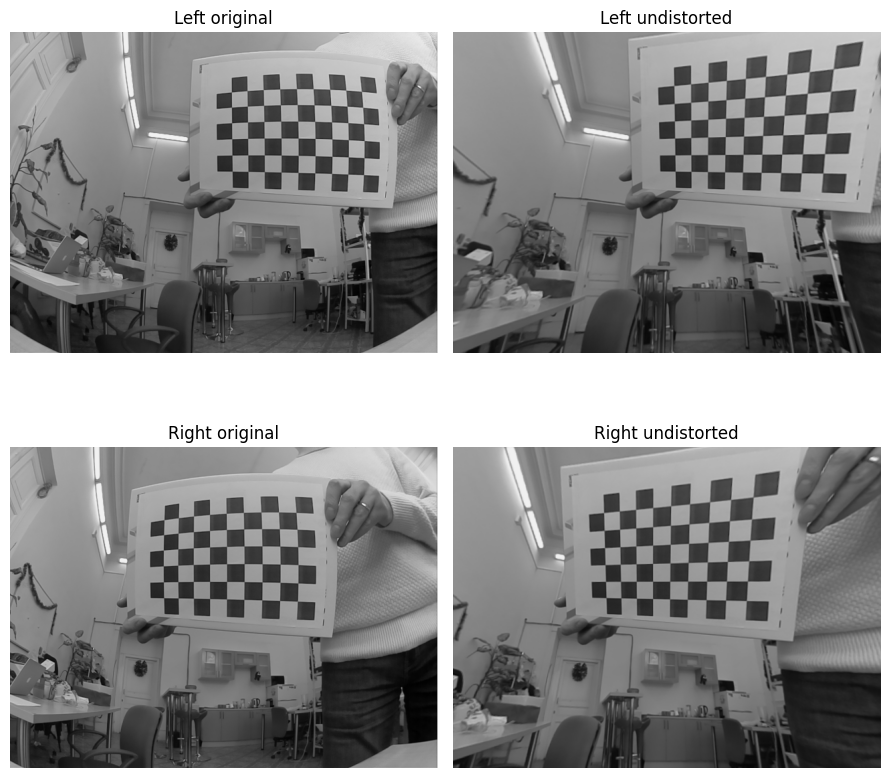

In [9]:
undistorted_left = undistort_image(
    image_bgr=sample_left_bgr,
    camera_matrix=left_calib["camera_matrix"],
    dist_coeffs=left_calib["dist_coeffs"],
)
undistorted_right = undistort_image(
    image_bgr=sample_right_bgr,
    camera_matrix=right_calib["camera_matrix"],
    dist_coeffs=right_calib["dist_coeffs"],
)

show_images_grid(
    images=[sample_left_bgr, undistorted_left, sample_right_bgr, undistorted_right],
    titles=["Left original", "Left undistorted", "Right original", "Right undistorted"],
    cols=2,
)


## Ćwiczenie 11.2: Kalibracja i rektyfikacja stereo

In [10]:
stereo_result = stereo_calibrate(
    object_points=calibration_data["object_points"],
    image_points_left=calibration_data["image_points_left"],
    image_points_right=calibration_data["image_points_right"],
    camera_matrix_left=left_calib["camera_matrix"],
    dist_coeffs_left=left_calib["dist_coeffs"],
    camera_matrix_right=right_calib["camera_matrix"],
    dist_coeffs_right=right_calib["dist_coeffs"],
    image_size=image_size,
    calib_criteria=CALIB_CRITERIA,
)

print("Stereo RMS:", stereo_result["rms"])
print("Macierz rotacji R:")
print(stereo_result["R"])
print("Wektor translacji T:")
print(stereo_result["T"].ravel())


Stereo RMS: 2.8426301960730207
Macierz rotacji R:
[[ 0.99981436 -0.00804476  0.01750812]
 [ 0.00785304  0.99990875  0.01099154]
 [-0.01759495 -0.01085201  0.9997863 ]]
Wektor translacji T:
[-2.52581435 -0.03933964 -0.15142705]


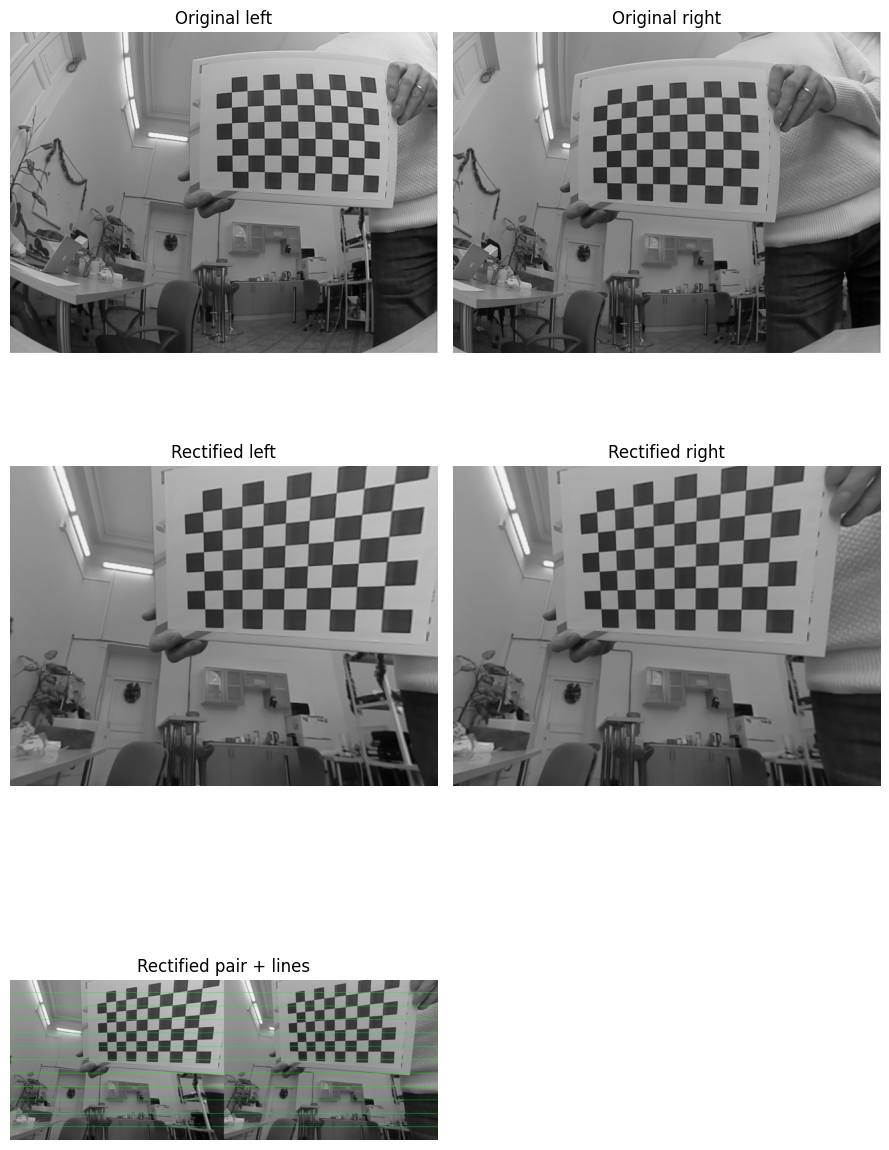

In [11]:
rectify_result = stereo_rectify_and_maps(
    camera_matrix_left=left_calib["camera_matrix"],
    dist_coeffs_left=left_calib["dist_coeffs"],
    camera_matrix_right=right_calib["camera_matrix"],
    dist_coeffs_right=right_calib["dist_coeffs"],
    image_size=image_size,
    R=stereo_result["R"],
    T=stereo_result["T"],
)

rect_left_bgr, rect_right_bgr = remap_stereo_pair(
    left_bgr=sample_left_bgr,
    right_bgr=sample_right_bgr,
    map1_left=rectify_result["map1_left"],
    map2_left=rectify_result["map2_left"],
    map1_right=rectify_result["map1_right"],
    map2_right=rectify_result["map2_right"],
)

lines_visualization = draw_horizontal_lines_on_pair(
    left_bgr=rect_left_bgr,
    right_bgr=rect_right_bgr,
    line_step=40,
)

show_images_grid(
    images=[sample_left_bgr, sample_right_bgr, rect_left_bgr, rect_right_bgr, lines_visualization],
    titles=["Original left", "Original right", "Rectified left", "Rectified right", "Rectified pair + lines"],
    cols=2,
)


## Ćwiczenie 11.3: Mapa dysparycji (BM i SGBM)

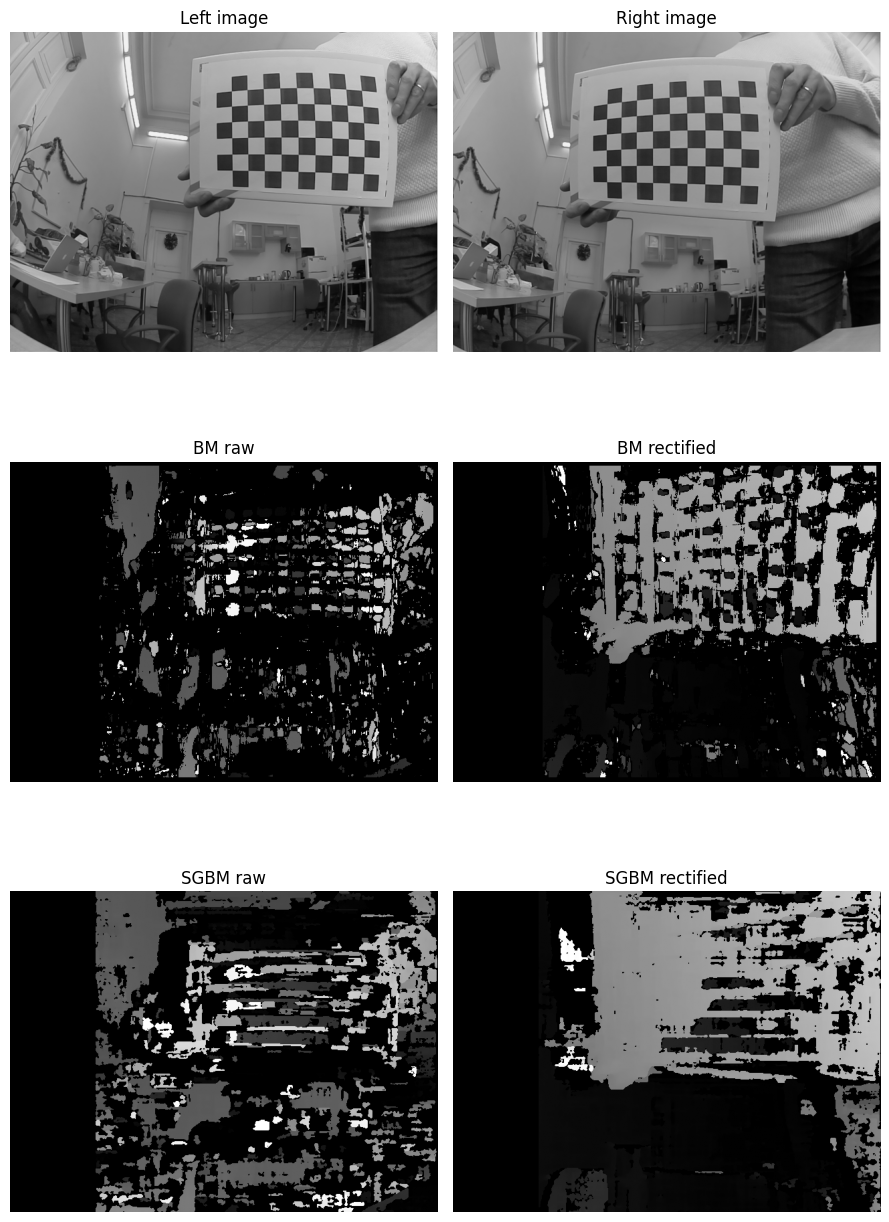

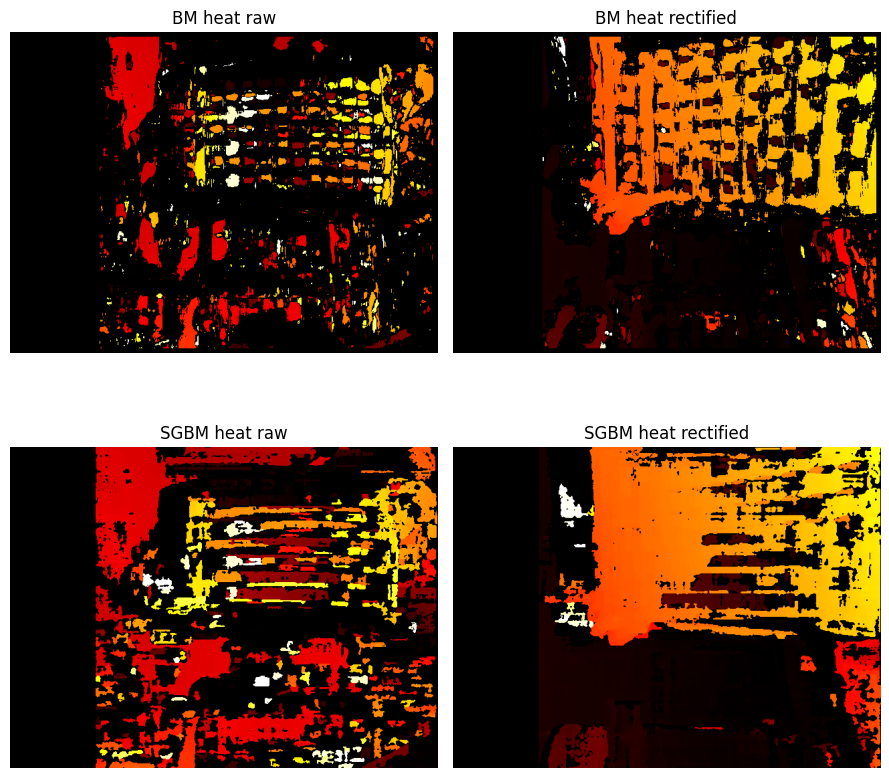

In [12]:
left_gray = bgr_to_gray(image=sample_left_bgr)
right_gray = bgr_to_gray(image=sample_right_bgr)
rect_left_gray = bgr_to_gray(image=rect_left_bgr)
rect_right_gray = bgr_to_gray(image=rect_right_bgr)

disp_bm_raw = compute_disparity_bm(
    left_gray=left_gray,
    right_gray=right_gray,
    num_disparities=NUM_DISPARITIES,
    block_size=BM_BLOCK_SIZE,
)
disp_bm_rect = compute_disparity_bm(
    left_gray=rect_left_gray,
    right_gray=rect_right_gray,
    num_disparities=NUM_DISPARITIES,
    block_size=BM_BLOCK_SIZE,
)

disp_sgbm_raw = compute_disparity_sgbm(
    left_gray=left_gray,
    right_gray=right_gray,
    min_disparity=SGBM_MIN_DISPARITY,
    num_disparities=NUM_DISPARITIES,
    block_size=SGBM_BLOCK_SIZE,
    uniqueness_ratio=SGBM_UNIQUENESS_RATIO,
    speckle_window_size=SGBM_SPECKLE_WINDOW_SIZE,
    speckle_range=SGBM_SPECKLE_RANGE,
    disp12_max_diff=SGBM_DISP12_MAX_DIFF,
)
disp_sgbm_rect = compute_disparity_sgbm(
    left_gray=rect_left_gray,
    right_gray=rect_right_gray,
    min_disparity=SGBM_MIN_DISPARITY,
    num_disparities=NUM_DISPARITIES,
    block_size=SGBM_BLOCK_SIZE,
    uniqueness_ratio=SGBM_UNIQUENESS_RATIO,
    speckle_window_size=SGBM_SPECKLE_WINDOW_SIZE,
    speckle_range=SGBM_SPECKLE_RANGE,
    disp12_max_diff=SGBM_DISP12_MAX_DIFF,
)

disp_bm_raw_u8 = normalize_disparity_to_uint8(disparity=disp_bm_raw)
disp_bm_rect_u8 = normalize_disparity_to_uint8(disparity=disp_bm_rect)
disp_sgbm_raw_u8 = normalize_disparity_to_uint8(disparity=disp_sgbm_raw)
disp_sgbm_rect_u8 = normalize_disparity_to_uint8(disparity=disp_sgbm_rect)

disp_bm_raw_heat = disparity_to_heatmap(disparity_uint8=disp_bm_raw_u8)
disp_bm_rect_heat = disparity_to_heatmap(disparity_uint8=disp_bm_rect_u8)
disp_sgbm_raw_heat = disparity_to_heatmap(disparity_uint8=disp_sgbm_raw_u8)
disp_sgbm_rect_heat = disparity_to_heatmap(disparity_uint8=disp_sgbm_rect_u8)

show_images_grid(
    images=[sample_left_bgr, sample_right_bgr, disp_bm_raw_u8, disp_bm_rect_u8, disp_sgbm_raw_u8, disp_sgbm_rect_u8],
    titles=["Left image", "Right image", "BM raw", "BM rectified", "SGBM raw", "SGBM rectified"],
    cols=2,
    cmap="gray",
)

show_images_grid(
    images=[disp_bm_raw_heat, disp_bm_rect_heat, disp_sgbm_raw_heat, disp_sgbm_rect_heat],
    titles=["BM heat raw", "BM heat rectified", "SGBM heat raw", "SGBM heat rectified"],
    cols=2,
)


## Ćwiczenie 11.3: Mapa dysparycji (BM i SGBM) na `data/example`

W tym zadaniu bierzemy **jeden obraz** z `data/example`, dzielimy go na lewą/prawą połówkę i pokazujemy korekcję zniekształceń oraz rektyfikację przed liczeniem dysparycji.

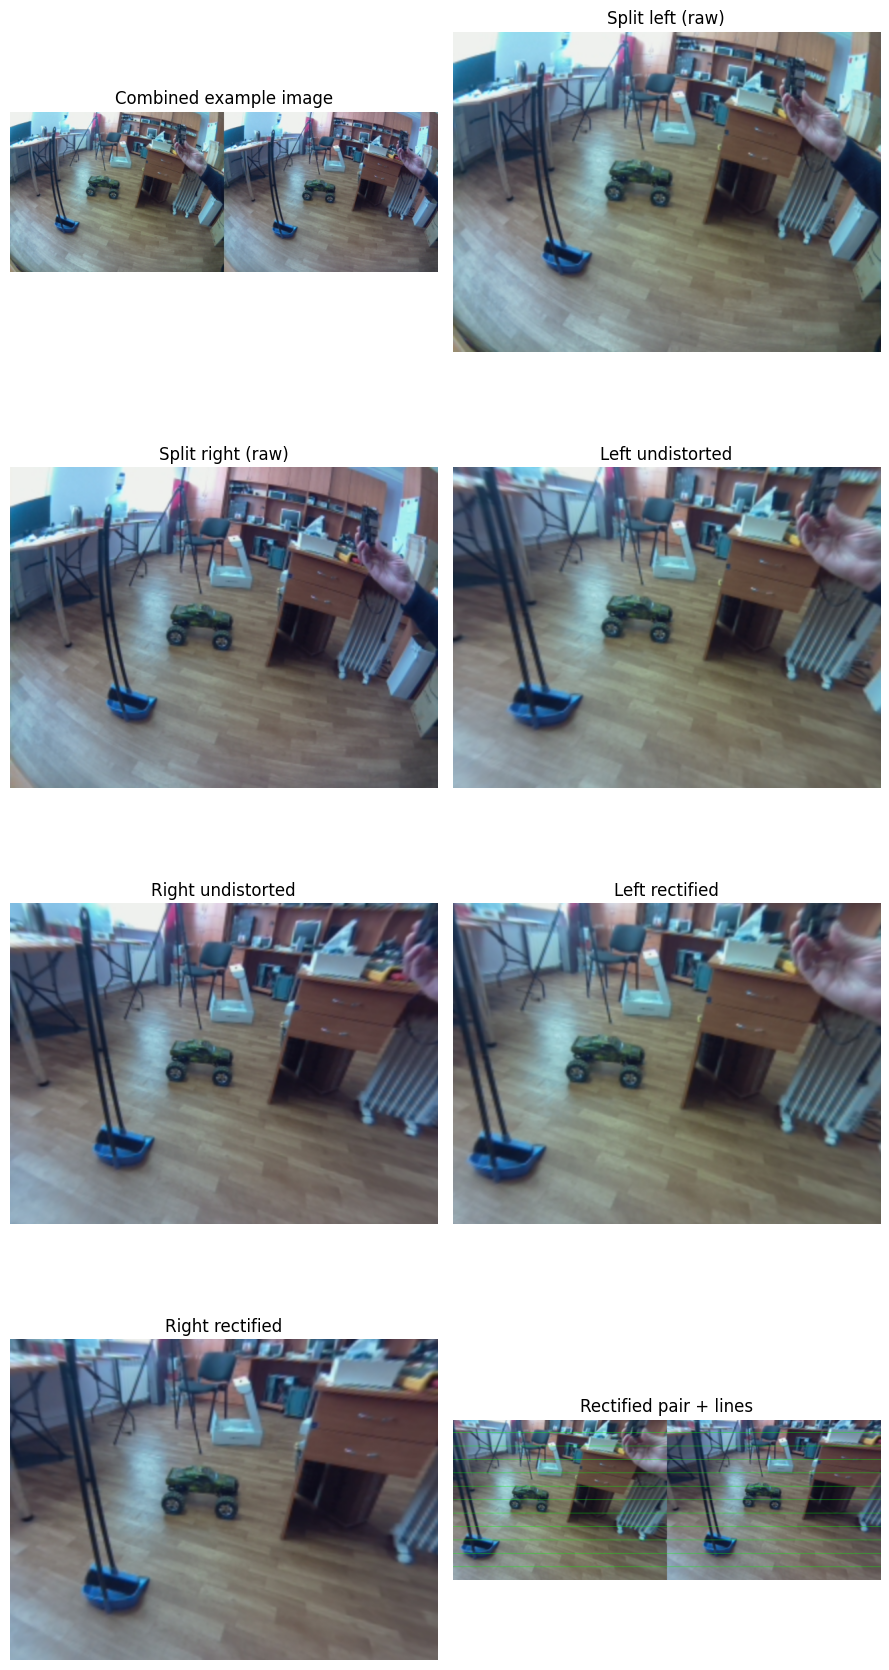

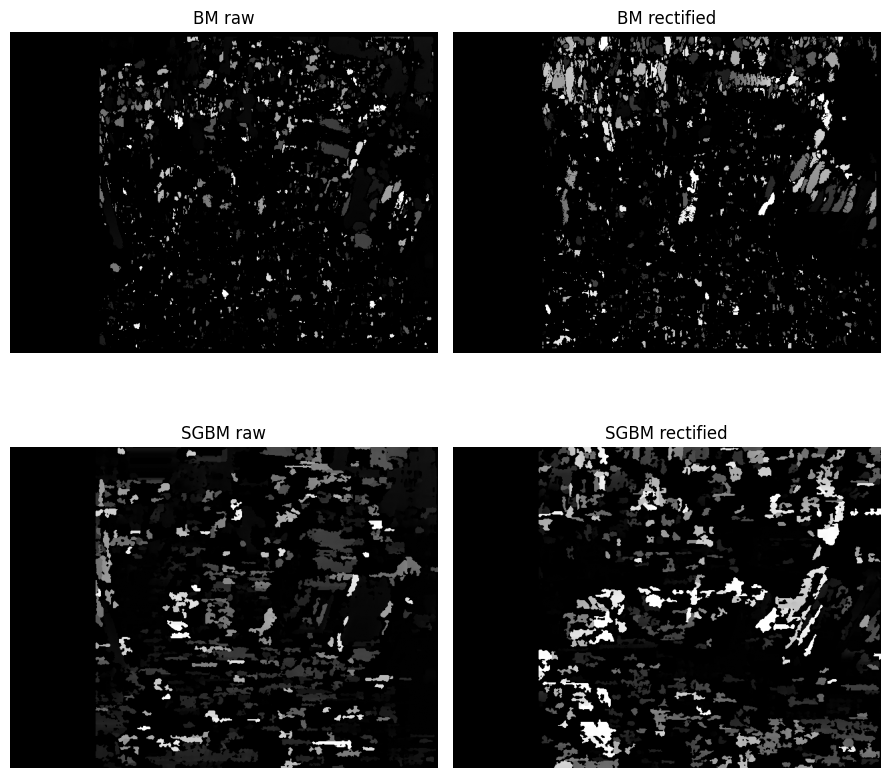

In [13]:
# 11.3: Bierzemy jeden obraz z data/example, dzielimy go na lewą/prawą połówkę,
# a potem używamy kalibracji do korekcji i rektyfikacji.
combined_example_bgr = load_combined_example_image(example_dir=EXAMPLE_DIR)
example_left_bgr, example_right_bgr = split_stereo_image_halves(combined_bgr=combined_example_bgr)

# Rozmiar musi pasować do map rektyfikacji wyznaczonych w 11.2.
if (example_left_bgr.shape[1], example_left_bgr.shape[0]) != image_size:
    example_left_bgr = cv2.resize(example_left_bgr, image_size, interpolation=cv2.INTER_LINEAR)
    example_right_bgr = cv2.resize(example_right_bgr, image_size, interpolation=cv2.INTER_LINEAR)

# Korekcja zniekształceń (intrinsics + dystorsja).
example_left_undist = undistort_image(
    image_bgr=example_left_bgr,
    camera_matrix=left_calib["camera_matrix"],
    dist_coeffs=left_calib["dist_coeffs"],
)
example_right_undist = undistort_image(
    image_bgr=example_right_bgr,
    camera_matrix=right_calib["camera_matrix"],
    dist_coeffs=right_calib["dist_coeffs"],
)

# Rektyfikacja stereo (wyprostowanie linii epipolarnych).
example_left_rect_bgr, example_right_rect_bgr = remap_stereo_pair(
    left_bgr=example_left_bgr,
    right_bgr=example_right_bgr,
    map1_left=rectify_result["map1_left"],
    map2_left=rectify_result["map2_left"],
    map1_right=rectify_result["map1_right"],
    map2_right=rectify_result["map2_right"],
)

lines_rect = draw_horizontal_lines_on_pair(
    left_bgr=example_left_rect_bgr,
    right_bgr=example_right_rect_bgr,
    line_step=40,
)

left_gray_raw = bgr_to_gray(image=example_left_bgr)
right_gray_raw = bgr_to_gray(image=example_right_bgr)
left_gray_rect = bgr_to_gray(image=example_left_rect_bgr)
right_gray_rect = bgr_to_gray(image=example_right_rect_bgr)

disp_bm_raw = compute_disparity_bm(
    left_gray=left_gray_raw,
    right_gray=right_gray_raw,
    num_disparities=NUM_DISPARITIES,
    block_size=BM_BLOCK_SIZE,
)
disp_bm_rect = compute_disparity_bm(
    left_gray=left_gray_rect,
    right_gray=right_gray_rect,
    num_disparities=NUM_DISPARITIES,
    block_size=BM_BLOCK_SIZE,
)
disp_sgbm_raw = compute_disparity_sgbm(
    left_gray=left_gray_raw,
    right_gray=right_gray_raw,
    min_disparity=SGBM_MIN_DISPARITY,
    num_disparities=NUM_DISPARITIES,
    block_size=SGBM_BLOCK_SIZE,
    uniqueness_ratio=SGBM_UNIQUENESS_RATIO,
    speckle_window_size=SGBM_SPECKLE_WINDOW_SIZE,
    speckle_range=SGBM_SPECKLE_RANGE,
    disp12_max_diff=SGBM_DISP12_MAX_DIFF,
)
disp_sgbm_rect = compute_disparity_sgbm(
    left_gray=left_gray_rect,
    right_gray=right_gray_rect,
    min_disparity=SGBM_MIN_DISPARITY,
    num_disparities=NUM_DISPARITIES,
    block_size=SGBM_BLOCK_SIZE,
    uniqueness_ratio=SGBM_UNIQUENESS_RATIO,
    speckle_window_size=SGBM_SPECKLE_WINDOW_SIZE,
    speckle_range=SGBM_SPECKLE_RANGE,
    disp12_max_diff=SGBM_DISP12_MAX_DIFF,
)

disp_bm_raw_u8 = normalize_disparity_to_uint8(disparity=disp_bm_raw)
disp_bm_rect_u8 = normalize_disparity_to_uint8(disparity=disp_bm_rect)
disp_sgbm_raw_u8 = normalize_disparity_to_uint8(disparity=disp_sgbm_raw)
disp_sgbm_rect_u8 = normalize_disparity_to_uint8(disparity=disp_sgbm_rect)

show_images_grid(
    images=[
        combined_example_bgr,
        example_left_bgr,
        example_right_bgr,
        example_left_undist,
        example_right_undist,
        example_left_rect_bgr,
        example_right_rect_bgr,
        lines_rect,
    ],
    titles=[
        "Combined example image",
        "Split left (raw)",
        "Split right (raw)",
        "Left undistorted",
        "Right undistorted",
        "Left rectified",
        "Right rectified",
        "Rectified pair + lines",
    ],
    cols=2,
)

show_images_grid(
    images=[disp_bm_raw_u8, disp_bm_rect_u8, disp_sgbm_raw_u8, disp_sgbm_rect_u8],
    titles=["BM raw", "BM rectified", "SGBM raw", "SGBM rectified"],
    cols=2,
    cmap="gray",
)


In [14]:
TUNE_NUM_DISPARITIES = NUM_DISPARITIES
TUNE_BM_BLOCK_SIZE = BM_BLOCK_SIZE
TUNE_SGBM_BLOCK_SIZE = SGBM_BLOCK_SIZE
TUNE_SGBM_UNIQUENESS_RATIO = SGBM_UNIQUENESS_RATIO

print("Aktualne parametry strojenia:")
print("TUNE_NUM_DISPARITIES:", TUNE_NUM_DISPARITIES)
print("TUNE_BM_BLOCK_SIZE:", TUNE_BM_BLOCK_SIZE)
print("TUNE_SGBM_BLOCK_SIZE:", TUNE_SGBM_BLOCK_SIZE)
print("TUNE_SGBM_UNIQUENESS_RATIO:", TUNE_SGBM_UNIQUENESS_RATIO)


Aktualne parametry strojenia:
TUNE_NUM_DISPARITIES: 128
TUNE_BM_BLOCK_SIZE: 15
TUNE_SGBM_BLOCK_SIZE: 5
TUNE_SGBM_UNIQUENESS_RATIO: 10
